# 05 · Wine Quality — Classification Models (logistic vs RF vs LightGBM)

## Part 5 — Classification Models

Now the models. We treat quality as a **multi-class classification** problem (the classify branch of
Part 4's fork) and pit three estimators against each other:

- **Logistic regression** — a linear baseline (with standardisation),
- **Random forest** — bagged trees, captures nonlinearity & interactions,
- **LightGBM** — gradient-boosted trees, usually the strongest tabular learner.

Part 2 warned that quality is a **nonlinear** signal, so we expect the trees to beat the linear model.
But the more important lesson of this notebook is *where every model fails the same way* — the rare
grades — which motivates the imbalance work in Part 7.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from src import modeling as M
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from lightgbm import LGBMClassifier
raw = data.clean()
Xtr, Xte, ytr, yte = M.split(raw)
models = {
    "logistic":      make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
    "random_forest": RandomForestClassifier(n_estimators=400, random_state=0, n_jobs=-1),
    "lightgbm":      LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=0, verbose=-1, n_jobs=-1),
}
print("train", len(ytr), "| test", len(yte))

setup ok | numpy 2.1.3 | pandas 2.3.3


train 3990 | test 1330


### 1. The scoreboard

Fit all three on the identical split and score with the full metric panel. The trees clearly beat
logistic on QWK; random forest and LightGBM are within noise of each other. Accuracy stalls around
0.55 — *not* because the models are bad, but because exact-grade prediction is genuinely hard (Part 2).

In [2]:
rows, preds = [], {}
for n, m in models.items():
    m.fit(Xtr, ytr); preds[n] = m.predict(Xte); rows.append(M.report(yte, preds[n], n))
board = pd.DataFrame(rows); print(board.to_string())
print("\nbest test QWK: %s (%.3f)" % (board.QWK.idxmax(), board.QWK.max()))

               accuracy  macro_F1    MAE    QWK
logistic          0.538     0.245  0.516  0.455
random_forest     0.555     0.259  0.489  0.507
lightgbm          0.550     0.262  0.505  0.494

best test QWK: random_forest (0.507)


### 2. Cross-validated, with error bars

A single split is noisy, so confirm the ranking with **stratified 5-fold QWK** (mean ± std). The
ordering holds: random forest ≈ LightGBM > logistic. The error bars overlap for the two tree models —
honestly, they're a tie, and we'll carry **LightGBM** forward as the workhorse (fast, native SHAP).

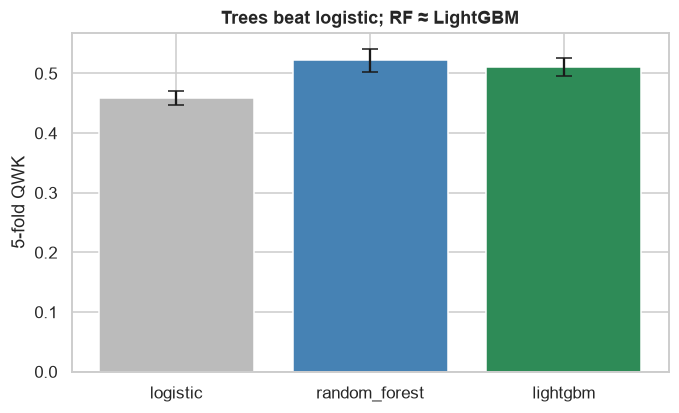

  logistic       QWK 0.459 ± 0.012
  random_forest  QWK 0.522 ± 0.019
  lightgbm       QWK 0.511 ± 0.015


In [3]:
Xall, yall = M.prep(data.dedup(raw))
cvs = {n: M.cv_qwk(m, Xall, yall, n=5) for n, m in models.items()}
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(cvs.keys(), [c.mean() for c in cvs.values()], yerr=[c.std() for c in cvs.values()],
       capsize=5, color=["#bbb", "steelblue", "seagreen"])
ax.set_ylabel("5-fold QWK"); ax.set_title("Trees beat logistic; RF ≈ LightGBM")
eda.savefig(fig, "p5_cv.png"); plt.show()
for n, c in cvs.items(): print("  %-14s QWK %.3f ± %.3f" % (n, c.mean(), c.std()))

### 3. The confusion matrix — *how* it's wrong matters

Row-normalised confusion for LightGBM (each row = what the true grade got predicted as). Two things
jump out: the mass sits **on and next to the diagonal** (errors are mostly off-by-one), and the
columns for grades 3, 4, 8, 9 are nearly **empty** — the model almost never *predicts* an extreme
grade. It has learned that betting on the crowded middle is safest.

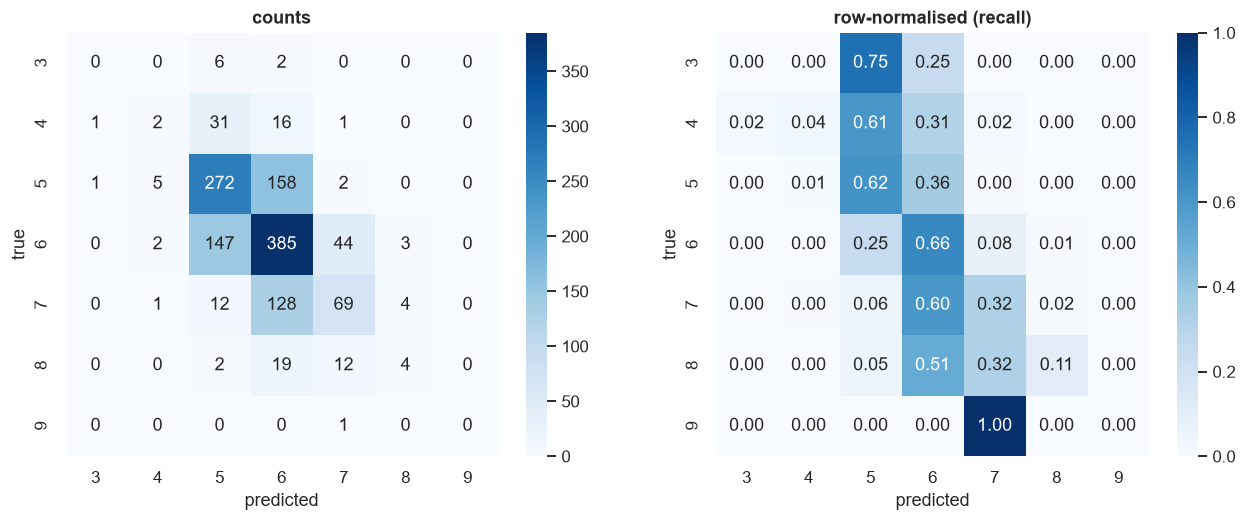

94.9% of predictions are within ±1 grade -> errors are ordinally small (why MAE/QWK are decent despite ~0.55 accuracy).


In [4]:
cm = confusion_matrix(yte, preds["lightgbm"], labels=range(3, 10))
cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(3,10), yticklabels=range(3,10), ax=ax[0]); ax[0].set_title("counts"); ax[0].set_xlabel("predicted"); ax[0].set_ylabel("true")
sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", xticklabels=range(3,10), yticklabels=range(3,10), ax=ax[1]); ax[1].set_title("row-normalised (recall)"); ax[1].set_xlabel("predicted"); ax[1].set_ylabel("true")
eda.savefig(fig, "p5_confusion.png"); plt.show()
within1 = (np.abs(yte.values - preds["lightgbm"]) <= 1).mean()
print("%.1f%% of predictions are within ±1 grade -> errors are ordinally small (why MAE/QWK are decent despite ~0.55 accuracy)." % (100*within1))

### 4. The rare-grade problem, named

Per-grade **recall** makes the failure explicit: the model catches ~60% of the common 5s and 6s but
**0% of quality-3 and quality-9** wines, and almost none of the 4s and 8s. This is the signature of
**class imbalance** — with 5 examples of grade 9, no loss function has any incentive to predict it.
Macro-F1 (which averages over grades equally) is low *because* of this. Part 7 attacks it directly.

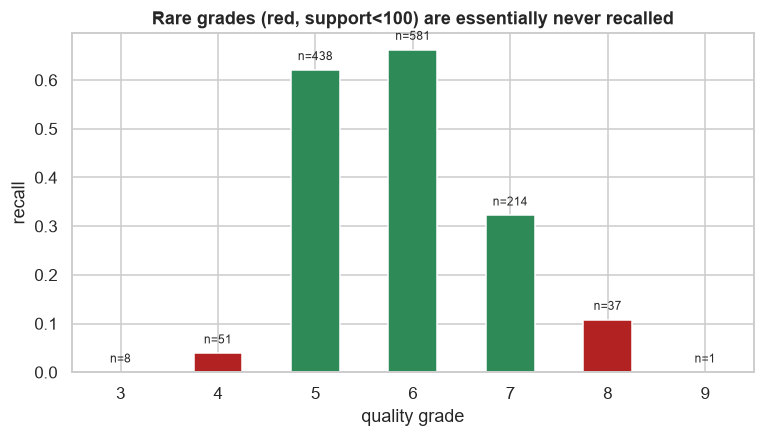

In [5]:
cr = classification_report(yte, preds["lightgbm"], labels=range(3,10), output_dict=True, zero_division=0)
rec = pd.Series({g: cr[str(g)]["recall"] for g in range(3,10)})
sup = pd.Series({g: int(cr[str(g)]["support"]) for g in range(3,10)})
fig, ax = plt.subplots(figsize=(8, 4))
rec.plot.bar(ax=ax, color=["firebrick" if s < 100 else "seagreen" for s in sup], rot=0)
ax.set_xlabel("quality grade"); ax.set_ylabel("recall"); ax.set_title("Rare grades (red, support<100) are essentially never recalled")
for i, g in enumerate(range(3,10)): ax.text(i, rec[g]+.02, f"n={sup[g]}", ha="center", fontsize=8)
eda.savefig(fig, "p5_recall.png"); plt.show()

### 5. What the best model leans on

A quick look at LightGBM's gain importance (full SHAP treatment in Part 9). **Alcohol** and the
engineered **alcohol/density** dominate, with **volatile acidity** and **free SO₂** next — exactly the
drivers the EDA flagged, now confirmed inside a predictive model.

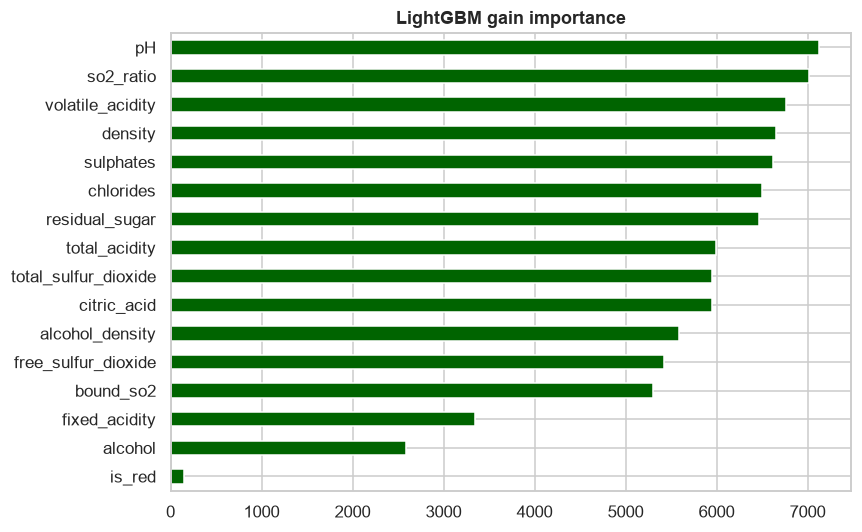

top drivers: ['pH', 'so2_ratio', 'volatile_acidity', 'density']


In [6]:
lgbm = models["lightgbm"]
imp = pd.Series(lgbm.feature_importances_, index=Xtr.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
imp.plot.barh(ax=ax, color="darkgreen"); ax.set_title("LightGBM gain importance"); fig.tight_layout()
eda.savefig(fig, "p5_importance.png"); plt.show()
print("top drivers:", list(imp.tail(4).index[::-1]))

### Takeaways

- **Trees beat the linear model** (RF/LightGBM QWK ≈ 0.51–0.52 vs logistic 0.46) — consistent with
  quality being a nonlinear signal (Part 2). RF and LightGBM are a statistical tie; we carry **LightGBM**
  forward.
- **Accuracy plateaus ~0.55**, but **95% of predictions are within ±1 grade** — the models are
  *ordinally* sensible even when not exact (hence respectable MAE/QWK).
- **The tails collapse**: 0% recall on grades 3 and 9. Plain multi-class loss has no reason to ever
  predict a rare grade — the core problem Part 7 tackles.
- Importance confirms the EDA: **alcohol / alcohol-density, volatile acidity, free SO₂**.

**Next — Part 6 (Regression & ordinal framing):** does treating quality as a *number* (regress + round)
or as a proper *ordinal* model beat classification on QWK? Often it does — because those framings bake
in the order that classification throws away.